In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [65]:
class Batsman(TypedDict):
    name: str
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str


In [66]:
def calculate_strike_rate(state: Batsman):
    balls = state["balls"]
    runs = state["runs"]
    strike_rate = (runs / balls) * 100
    state["strike_rate"] = strike_rate
    return {'strike_rate': strike_rate}

In [67]:
def calculate_balls_per_boundary(state: Batsman):
    balls = state["balls"]
    fours = state["fours"]
    sixes = state["sixes"]
    total_boundaries = fours + sixes
    if total_boundaries > 0:
        balls_per_boundary = balls / total_boundaries
    else:
        balls_per_boundary = float('inf')  # Avoid division by zero
    return {'balls_per_boundary': balls_per_boundary}

In [68]:
def calculate_boundary_percentage(state: Batsman):
    balls = state["balls"]
    fours = state["fours"]
    sixes = state["sixes"]
    total_boundaries = fours + sixes
    if balls > 0:
        boundary_percentage = (total_boundaries / balls) * 100
    else:
        boundary_percentage = 0.0  # Avoid division by zero
    state["boundary_percentage"] = boundary_percentage
    return {'boundary_percentage': boundary_percentage}

In [69]:
def summary_state(state: Batsman):
    summary =  """{state['name']} 
    scored {state['runs']} runs in {state['balls']}
      balls with a strike rate of {state['strike_rate']:.2f} 
      and hit {state['fours']} fours and {state['sixes']} sixes."""
    state['summary'] = summary
    return {'summary': summary}
    

In [70]:
graph = StateGraph(Batsman)

#add node
graph.add_node('calculate_sr', calculate_strike_rate)
graph.add_node('calculate_bpb', calculate_balls_per_boundary)
graph.add_node('calculate_bp', calculate_boundary_percentage)
graph.add_node('summary', summary_state)

#add edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_bp')
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_bp', 'summary')
graph.add_edge('summary', END)

#Compile
workflow = graph.compile()

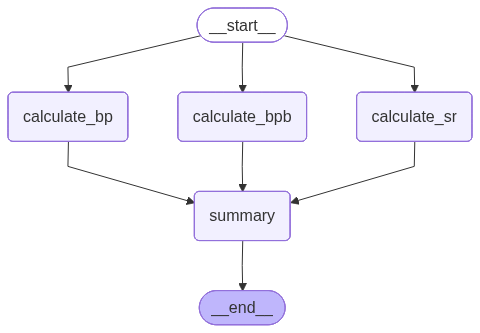

In [71]:
workflow

In [72]:
initial_state = {
    "name": "Virat Kohli",
    "runs": 50,
    "balls": 30,
    "fours": 5,
    "sixes": 2,
}

final_state = workflow.invoke(initial_state)


In [73]:
print(final_state)

{'name': 'Virat Kohli', 'runs': 50, 'balls': 30, 'fours': 5, 'sixes': 2, 'strike_rate': 166.66666666666669, 'balls_per_boundary': 4.285714285714286, 'boundary_percentage': 23.333333333333332, 'summary': "{state['name']} \n    scored {state['runs']} runs in {state['balls']}\n      balls with a strike rate of {state['strike_rate']:.2f} \n      and hit {state['fours']} fours and {state['sixes']} sixes."}


In [74]:
print("Name: ", final_state["name"])
print("Runs: ", final_state["runs"])
print("Balls: ", final_state["balls"])
print("Fours: ", final_state["fours"])
print("Sixes: ", final_state["sixes"])
print("Strike Rate: ", final_state["strike_rate"])
print("Balls per Boundary: ", final_state["balls_per_boundary"])
print("Boundary Percentage: ", final_state["boundary_percentage"])
print("Summary: ", final_state["summary"])

Name:  Virat Kohli
Runs:  50
Balls:  30
Fours:  5
Sixes:  2
Strike Rate:  166.66666666666669
Balls per Boundary:  4.285714285714286
Boundary Percentage:  23.333333333333332
Summary:  {state['name']} 
    scored {state['runs']} runs in {state['balls']}
      balls with a strike rate of {state['strike_rate']:.2f} 
      and hit {state['fours']} fours and {state['sixes']} sixes.
